# Análise da Participação Feminina nas Olimpíadas

Atualmente, a presença feminina nos Jogos Olímpicos é vista como algo natural. Estamos acostumados a acompanhar grandes atletas medalhistas, como Rebeca Andrade, Simone Biles e Rafaela Silva, entre tantas outras referências do esporte mundial. No entanto, essa realidade nem sempre existiu. Durante décadas, as mulheres enfrentaram barreiras sociais, culturais e institucionais para conquistar espaço nas competições olímpicas. Com talento, dedicação e perseverança, elas transformaram esse cenário e passaram a ocupar um papel de destaque no esporte de alto rendimento.

Neste trabalho, analisaremos como ocorreu a evolução da participação feminina nos Jogos Olímpicos entre 1896 e 2016, destacando os principais marcos históricos, as diferenças entre modalidades esportivas e os impactos geopolíticos dessa transformação. Essa trajetória reflete não apenas mudanças no esporte, mas também importantes avanços sociais ao longo da história.

### Importação e primeira analise dos dados:

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

sns.set_theme(
    style="whitegrid",
    palette="colorblind"
)

df = pd.read_csv("athlete_events.csv")

In [94]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [95]:
df.shape

(271116, 15)

## Linha do Tempo
Participação de atletas por sexo ao longo das Olimpíadas

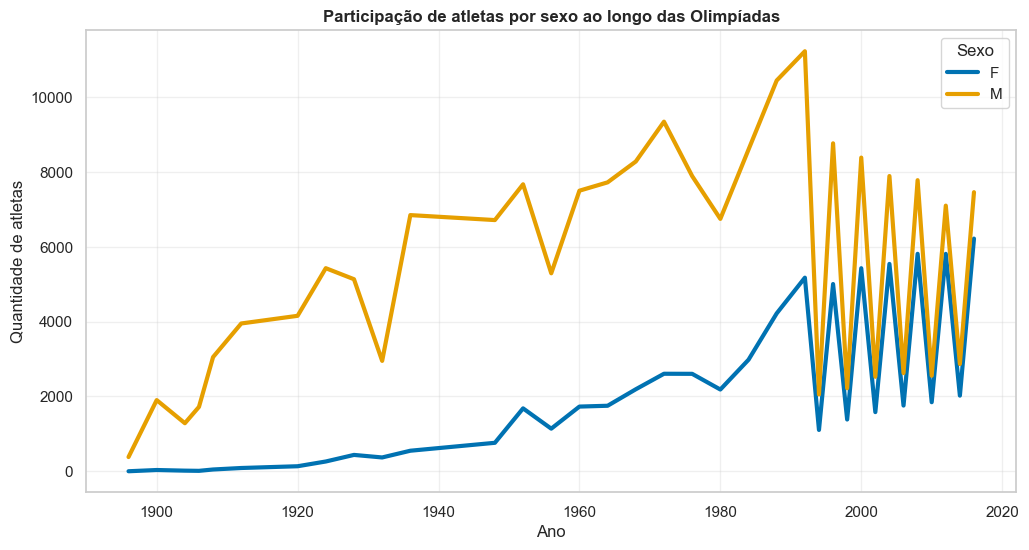

In [ ]:
participacao = (
    df.groupby(["Year","Sex"])
      .size()
      .unstack(fill_value=0)
)

participacao.plot(
    figsize=(12,6),
    linewidth=3,
    color=["#0072B2", "#E69F00"]
)

plt.grid(alpha=0.3)
plt.legend(title="Sexo")
plt.title("Participação de atletas por sexo ao longo das Olimpíadas")
plt.xlabel("Ano")
plt.ylabel("Quantidade de atletas")
plt.show()

Ao longo de todo o período analisado, observa-se um crescimento consistente da participação feminina nos Jogos Olímpicos. Enquanto nas primeiras edições a presença de mulheres era praticamente inexistente, a partir da segunda metade do século XX ocorre uma aceleração significativa desse crescimento. Embora a participação masculina continue superior durante grande parte da história olímpica, observa-se uma redução progressiva dessa diferença, evidenciando a busca por maior equilíbrio de gênero nas competições.

A partir da década de 1970 percebe-se uma expansão mais acelerada da participação feminina, reflexo da inclusão de novas modalidades e das transformações sociais relacionadas aos direitos das mulheres. Este gráfico evidencia a transformação do papel da mulher dentro do movimento olímpico ao longo de mais de um século.

## Barras Horizontais
Quantidade de atletas mulheres por esporte

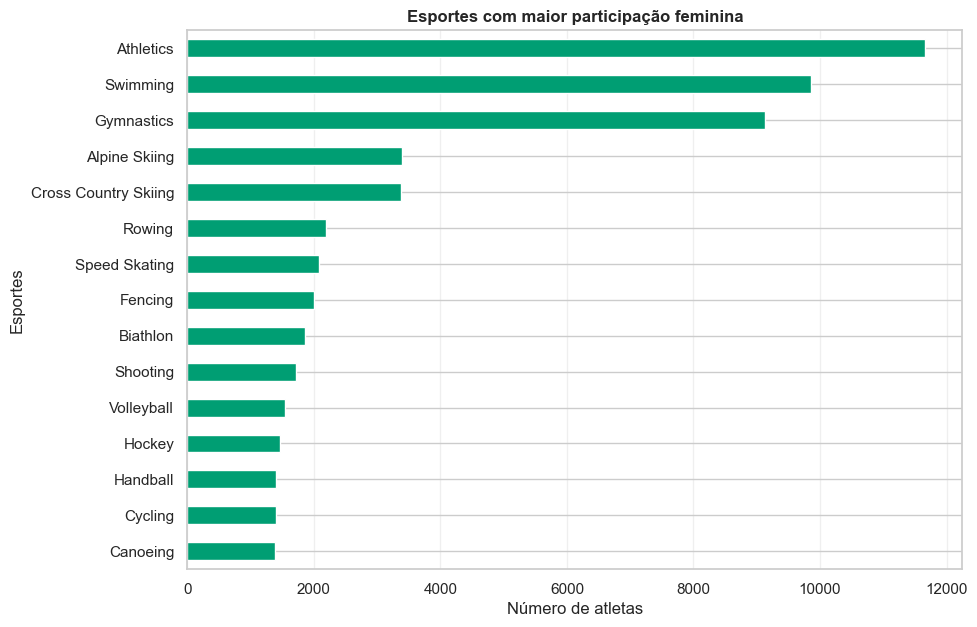

In [124]:
mulheres = df[df["Sex"]=="F"]

esportes = (
    mulheres["Sport"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,7))

esportes.sort_values().plot.barh(
    color="#009E73"
)

plt.grid(axis="x", alpha=0.3)

plt.title("Esportes com maior participação feminina")
plt.ylabel("Esportes")
plt.xlabel("Número de atletas")
plt.show()

Apesar do crescimento geral da participação feminina, esse aumento não ocorreu de forma homogênea entre as modalidades esportivas. As modalidades mais tradicionais dos Jogos Olímpicos concentram o maior número de atletas mulheres, indicando que sua consolidação ao longo do tempo favoreceu uma maior inclusão feminina.

## Mapa Mundial 🌎
Quantidade de Medalhas por País!


In [ ]:
import plotly.express as px

In [ ]:
medalhas = (
    df[df["Medal"].notna()]
    .groupby(["NOC", "Sex"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

In [ ]:
medalhas["Total"] = medalhas["F"] + medalhas["M"]

medalhas["Percentual Feminino"] = (
    medalhas["F"] / medalhas["Total"] * 100
).round(1)

In [129]:
fig = px.choropleth(
    medalhas,
    locations="NOC",
    locationmode="ISO-3",
    color="F",
    hover_name="NOC",
    hover_data={
        "F": True,
        "M": True,
        "Total": True,
        "Percentual Feminino": True
    },
    color_continuous_scale="Viridis",
    title="Medalhas femininas por país"
)

fig.show()

Embora a participação feminina tenha crescido consistentemente ao longo das décadas, essa evolução não ocorreu de maneira uniforme em todos os países. O mapa evidencia que a conquista de medalhas femininas está concentrada em um número relativamente pequeno de países. Estados Unidos, China, Rússia, Alemanha e Reino Unido destacam-se como os principais polos, concentrando uma parcela significativa do quadro histórico de medalhas femininas.

Essa disparidade no mapa reflete não apenas o investimento no esporte de alto rendimento, mas também o peso de fatores sociais e culturais. Em diversas regiões, a trajetória das mulheres até os Jogos Olímpicos ainda é condicionada por barreiras estruturais que vão desde o acesso restrito a modalidades específicas até desafios relacionados à permanência e ao reconhecimento profissional de atletas femininas.

## Evolução da porcentagem feminina

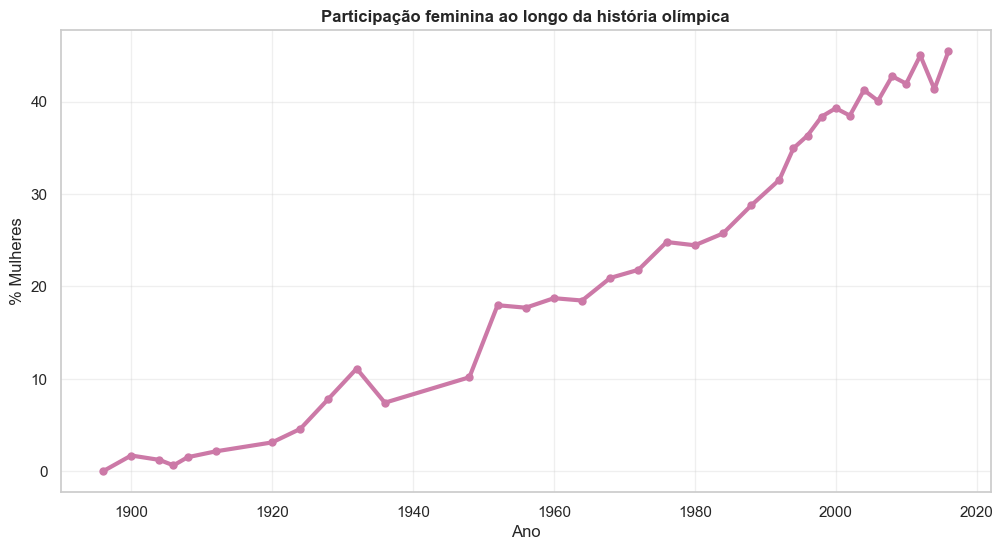

In [131]:
participacao = (
    df.groupby(["Year","Sex"])
      .size()
      .unstack(fill_value=0)
)

participacao["Percentual Feminino"] = (
    participacao["F"] /
    (participacao["F"] + participacao["M"])
) * 100

plt.figure(figsize=(12,6))

plt.plot(
    participacao.index,
    participacao["Percentual Feminino"],
    color="#CC79A7",
    linewidth=3,
    marker="o",
    markersize=5
)

plt.grid(alpha=0.3)

plt.ylabel("% Mulheres")
plt.xlabel("Ano")
plt.title("Participação feminina ao longo da história olímpica")

plt.show()


A análise demonstra que a inclusão feminina nas Olimpíadas ocorreu de forma gradual, acompanhando mudanças sociais e culturais. Os dados evidenciam que a participação das mulheres deixou de ser exceção para tornar-se elemento essencial do movimento olímpico moderno. Além disso, países que investiram no esporte feminino obtiveram resultados expressivos em medalhas, indicando que políticas de incentivo podem gerar benefícios esportivos e sociais.

No entanto, as diferenças observadas entre os países indicam que o caminho rumo à igualdade de oportunidades no esporte ainda é um desafio, reforçando a importância de iniciativas que ampliem o acesso e o desenvolvimento do esporte feminino para que mulheres de todo o mundo tenham condições de desenvolver seu potencial esportivo.